# Ridge Regression (L2)

**Flow:** correlated features → coefficient shrinkage → alpha selection by CV on training data → held-out test evaluation.

Ridge adds an L2 penalty. Scale features **inside** the Pipeline so a shared alpha penalizes coefficients comparably and the scaler is fit only on training rows (no leakage).

## 1. Setup and versions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

rng = np.random.default_rng(42)

OKABE_ITO = [
    '#0072B2',  # blue
    '#E69F00',  # orange
    '#009E73',  # bluish green
    '#D55E00',  # vermillion
    '#CC79A7',  # reddish purple
    '#56B4E9',  # sky blue
    '#F0E442',  # yellow
    '#000000',  # black
]


In [2]:
# Environment / version info for reproducibility
import sys
import numpy as np
import scipy
import sklearn
import matplotlib

print('Python      :', sys.version.split()[0])
print('numpy       :', np.__version__)
print('scipy       :', scipy.__version__)
print('scikit-learn:', sklearn.__version__)
print('matplotlib  :', matplotlib.__version__)


Python      : 3.9.25
numpy       : 1.26.4
scipy       : 1.13.1
scikit-learn: 1.4.2
matplotlib  : 3.8.4


## 2. Data with correlated features, split before fitting
Features x1 and x2 are strongly correlated; x3 is noise. We split into train/test **before** any fitting or scaling.

In [3]:
z = rng.normal(size=160)
X = np.c_[z, z + rng.normal(0, 0.08, size=160), rng.normal(size=160)]
y = 2 * z + rng.normal(0, 1, size=160)
feature_names = ['x1', 'x2 (~x1)', 'x3 (noise)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=4
)
print(f'Train/test sizes: {X_train.shape[0]} / {X_test.shape[0]}')


Train/test sizes: 112 / 48


## 3. Coefficient shrinkage path (fit on training data)
As alpha grows, coefficients shrink toward zero. Each series uses a distinct color **and** linestyle so the plot is readable without relying on color alone.

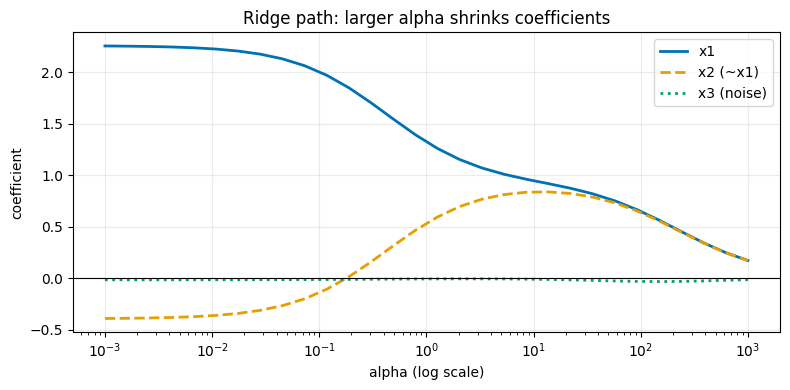

In [4]:
alphas = np.logspace(-3, 3, 30)
coefs = []
for a in alphas:
    pipe = Pipeline([
        ('scale', StandardScaler()),
        ('ridge', Ridge(alpha=a)),
    ]).fit(X_train, y_train)
    coefs.append(pipe.named_steps['ridge'].coef_)
coefs = np.array(coefs)

linestyles = ['-', '--', ':']
plt.figure(figsize=(8, 4))
for j, name in enumerate(feature_names):
    plt.semilogx(alphas, coefs[:, j], color=OKABE_ITO[j],
                 ls=linestyles[j], lw=2, label=name)
plt.axhline(0, color='black', lw=0.8)
plt.title('Ridge path: larger alpha shrinks coefficients')
plt.xlabel('alpha (log scale)'); plt.ylabel('coefficient')
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()


## 4. Select alpha by cross-validation on TRAINING data
`RidgeCV` performs cross-validation over the alpha grid using only the training data. The scaler lives in the Pipeline so it is fit per-fold on training rows only.

Best alpha selected by CV: 0.788


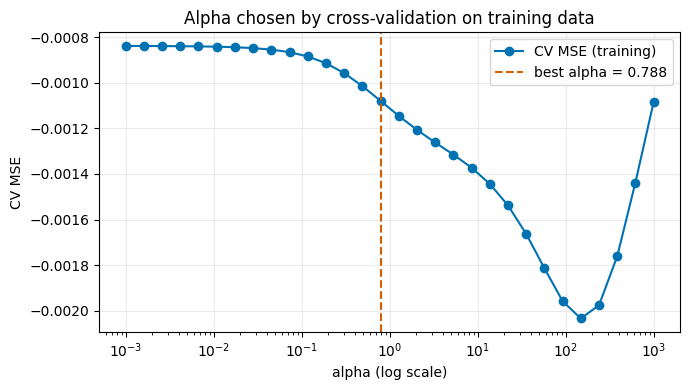

In [5]:
ridge_cv = Pipeline([
    ('scale', StandardScaler()),
    ('ridge', RidgeCV(alphas=alphas, scoring='neg_mean_squared_error',
                      store_cv_values=True)),
]).fit(X_train, y_train)

best_alpha = ridge_cv.named_steps['ridge'].alpha_
cv_mse = ridge_cv.named_steps['ridge'].cv_values_.mean(axis=0)
print(f'Best alpha selected by CV: {best_alpha:.4g}')

plt.figure(figsize=(7, 4))
plt.semilogx(alphas, cv_mse, color=OKABE_ITO[0], marker='o',
             label='CV MSE (training)')
plt.axvline(best_alpha, color=OKABE_ITO[3], ls='--',
            label=f'best alpha = {best_alpha:.3g}')
plt.title('Alpha chosen by cross-validation on training data')
plt.xlabel('alpha (log scale)'); plt.ylabel('CV MSE')
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()


## 5. Final evaluation on held-out test data
We evaluate the CV-selected model **once** on the untouched test set and compare against a nearly unregularized Ridge (alpha ~ 0).

model                      test R2    test MSE
----------------------------------------------
Ridge (alpha~0)              0.507       1.288
RidgeCV (alpha=0.788)        0.503       1.299


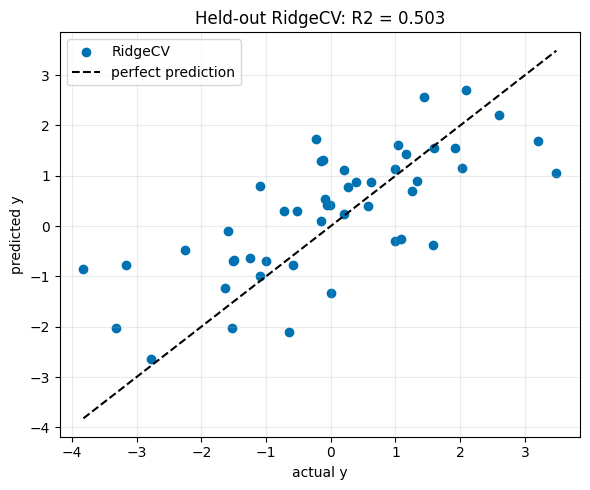

In [6]:
test_pred = ridge_cv.predict(X_test)

ols_like = Pipeline([
    ('scale', StandardScaler()),
    ('ridge', Ridge(alpha=1e-8)),
]).fit(X_train, y_train)
ols_pred = ols_like.predict(X_test)

rows = [
    ('Ridge (alpha~0)', r2_score(y_test, ols_pred),
     mean_squared_error(y_test, ols_pred)),
    (f'RidgeCV (alpha={best_alpha:.3g})', r2_score(y_test, test_pred),
     mean_squared_error(y_test, test_pred)),
]
print(f'{"model":<24}{"test R2":>10}{"test MSE":>12}')
print('-' * 46)
for name, r2, mse in rows:
    print(f'{name:<24}{r2:>10.3f}{mse:>12.3f}')

lim = [min(y_test.min(), test_pred.min()),
       max(y_test.max(), test_pred.max())]
plt.figure(figsize=(6, 5))
plt.scatter(y_test, test_pred, color=OKABE_ITO[0], label='RidgeCV')
plt.plot(lim, lim, color='black', ls='--', label='perfect prediction')
plt.title(f'Held-out RidgeCV: R2 = {r2_score(y_test, test_pred):.3f}')
plt.xlabel('actual y'); plt.ylabel('predicted y')
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()


## Takeaways
- Ridge keeps all features but reduces variance from correlation.
- Choose alpha by CV on **training** data (RidgeCV in a Pipeline).
- Report the final metric once on held-out test data.